In [19]:
image_path = "image.png"

In [20]:
import cv2 as cv
img = cv.imread(image_path, cv.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(f"Image not found at path: {image_path}")
img = img.astype(float)
height, width = img.shape
print(f"Width: {width}, Height: {height}")

Width: 512, Height: 512


In [21]:
import numpy as np
padded_img = np.pad(img, pad_width=1, mode='constant', constant_values=0)

In [22]:
def sobel_filter(image, direction):
    h, w = image.shape
    if direction != 'x' and direction != 'y':
        raise ValueError("Direction must be 'x' or 'y'")
    sobel_array = [[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]] if direction == 'x' else [[-1, -2, -1], [0, 0, 0], [1, 2, 1]]
    
    empty_array = np.zeros((h, w))
    for y in range(1, h-2):
        for x in range(1, w-2):
            selected_region = image[y:y + 3, x:x + 3]
            empty_array[y, x] = np.sum(sobel_array * selected_region)
            empty_array[y, x] = np.clip(empty_array[y, x], 0, 255)
    return empty_array

def prewitt_filter(image, direction):
    h, w = image.shape
    if direction != 'x' and direction != 'y':
        raise ValueError("Direction must be 'x' or 'y'")
    prewitt_array = [[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]] if direction == 'x' else [[-1, -1, -1], [0, 0, 0], [1, 1, 1]]
    empty_array = np.zeros((h, w))
    for y in range(1, h-2):
        for x in range(1, w-2):
            selected_region = image[y:y + 3, x:x + 3]
            empty_array[y, x] = np.sum(prewitt_array * selected_region)
            empty_array[y, x] = np.clip(empty_array[y, x], 0, 255)
    return empty_array
def laplacian_filter(image, type):
    if type != 4 and type != 8:
        raise ValueError("Laplacian filter type must be 4 or 8")
    laplacian_array = [[0, 1, 0],[1, -4, 1],[0, 1, 0]] if type == 4 else [[1, 1, 1],[1, -8, 1],[1, 1, 1]]
    h, w = image.shape
    empty_array = np.zeros((h, w))
    for y in range(1, h - 2):
        for x in range(1, w - 2):
            selected_region = image[y : y + 3, x : x + 3]
            empty_array[y, x] = np.sum(laplacian_array * selected_region)
            empty_array[y, x] = np.clip(empty_array[y, x], 0, 255)
    return empty_array

def sharpening(image):
    sharpening_array = [[-1, -1, -1],[-1, 9, -1],[-1, -1, -1]]
    h, w = image.shape
    empty_array = np.zeros((h, w))
    for y in range(1, h-2):
        for x in range(1, w-2):
            selected_region = image[y:y + 3, x:x + 3]
            empty_array[y, x] = np.sum(sharpening_array * selected_region)
            empty_array[y, x] = np.clip(empty_array[y, x], 0, 255)
    return empty_array


In [23]:
import numpy as np
sobel_filtered_img_x = sobel_filter(padded_img, 'x')
sobel_filtered_img_y = sobel_filter(padded_img, "y")
sobel_concat = np.hstack((sobel_filtered_img_x, sobel_filtered_img_y))

In [24]:
import numpy as np

prewitt_filtered_img_x = prewitt_filter(padded_img, "x")
prewitt_filtered_img_y = prewitt_filter(padded_img, "y")
prewitt_concat = np.hstack((prewitt_filtered_img_x, prewitt_filtered_img_y))

In [25]:
import numpy as np
laplacian_filtered_img_4 = laplacian_filter(padded_img, 4)
laplacian_filtered_img_8 = laplacian_filter(padded_img, 8)
laplacian_concat = np.hstack((laplacian_filtered_img_4, laplacian_filtered_img_8))

In [26]:
import numpy as np
sharpening_filtered_img = sharpening(padded_img)
sharpening_empty = np.full(sharpening_filtered_img.shape, 255)
sharpening_concat = np.hstack((sharpening_filtered_img, sharpening_empty))


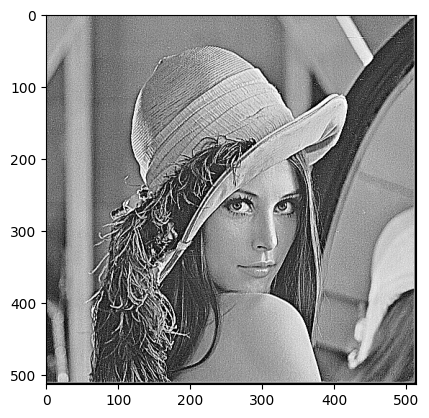

In [27]:
import matplotlib.pyplot as plt
plt.imshow(sharpening_filtered_img, cmap='gray')

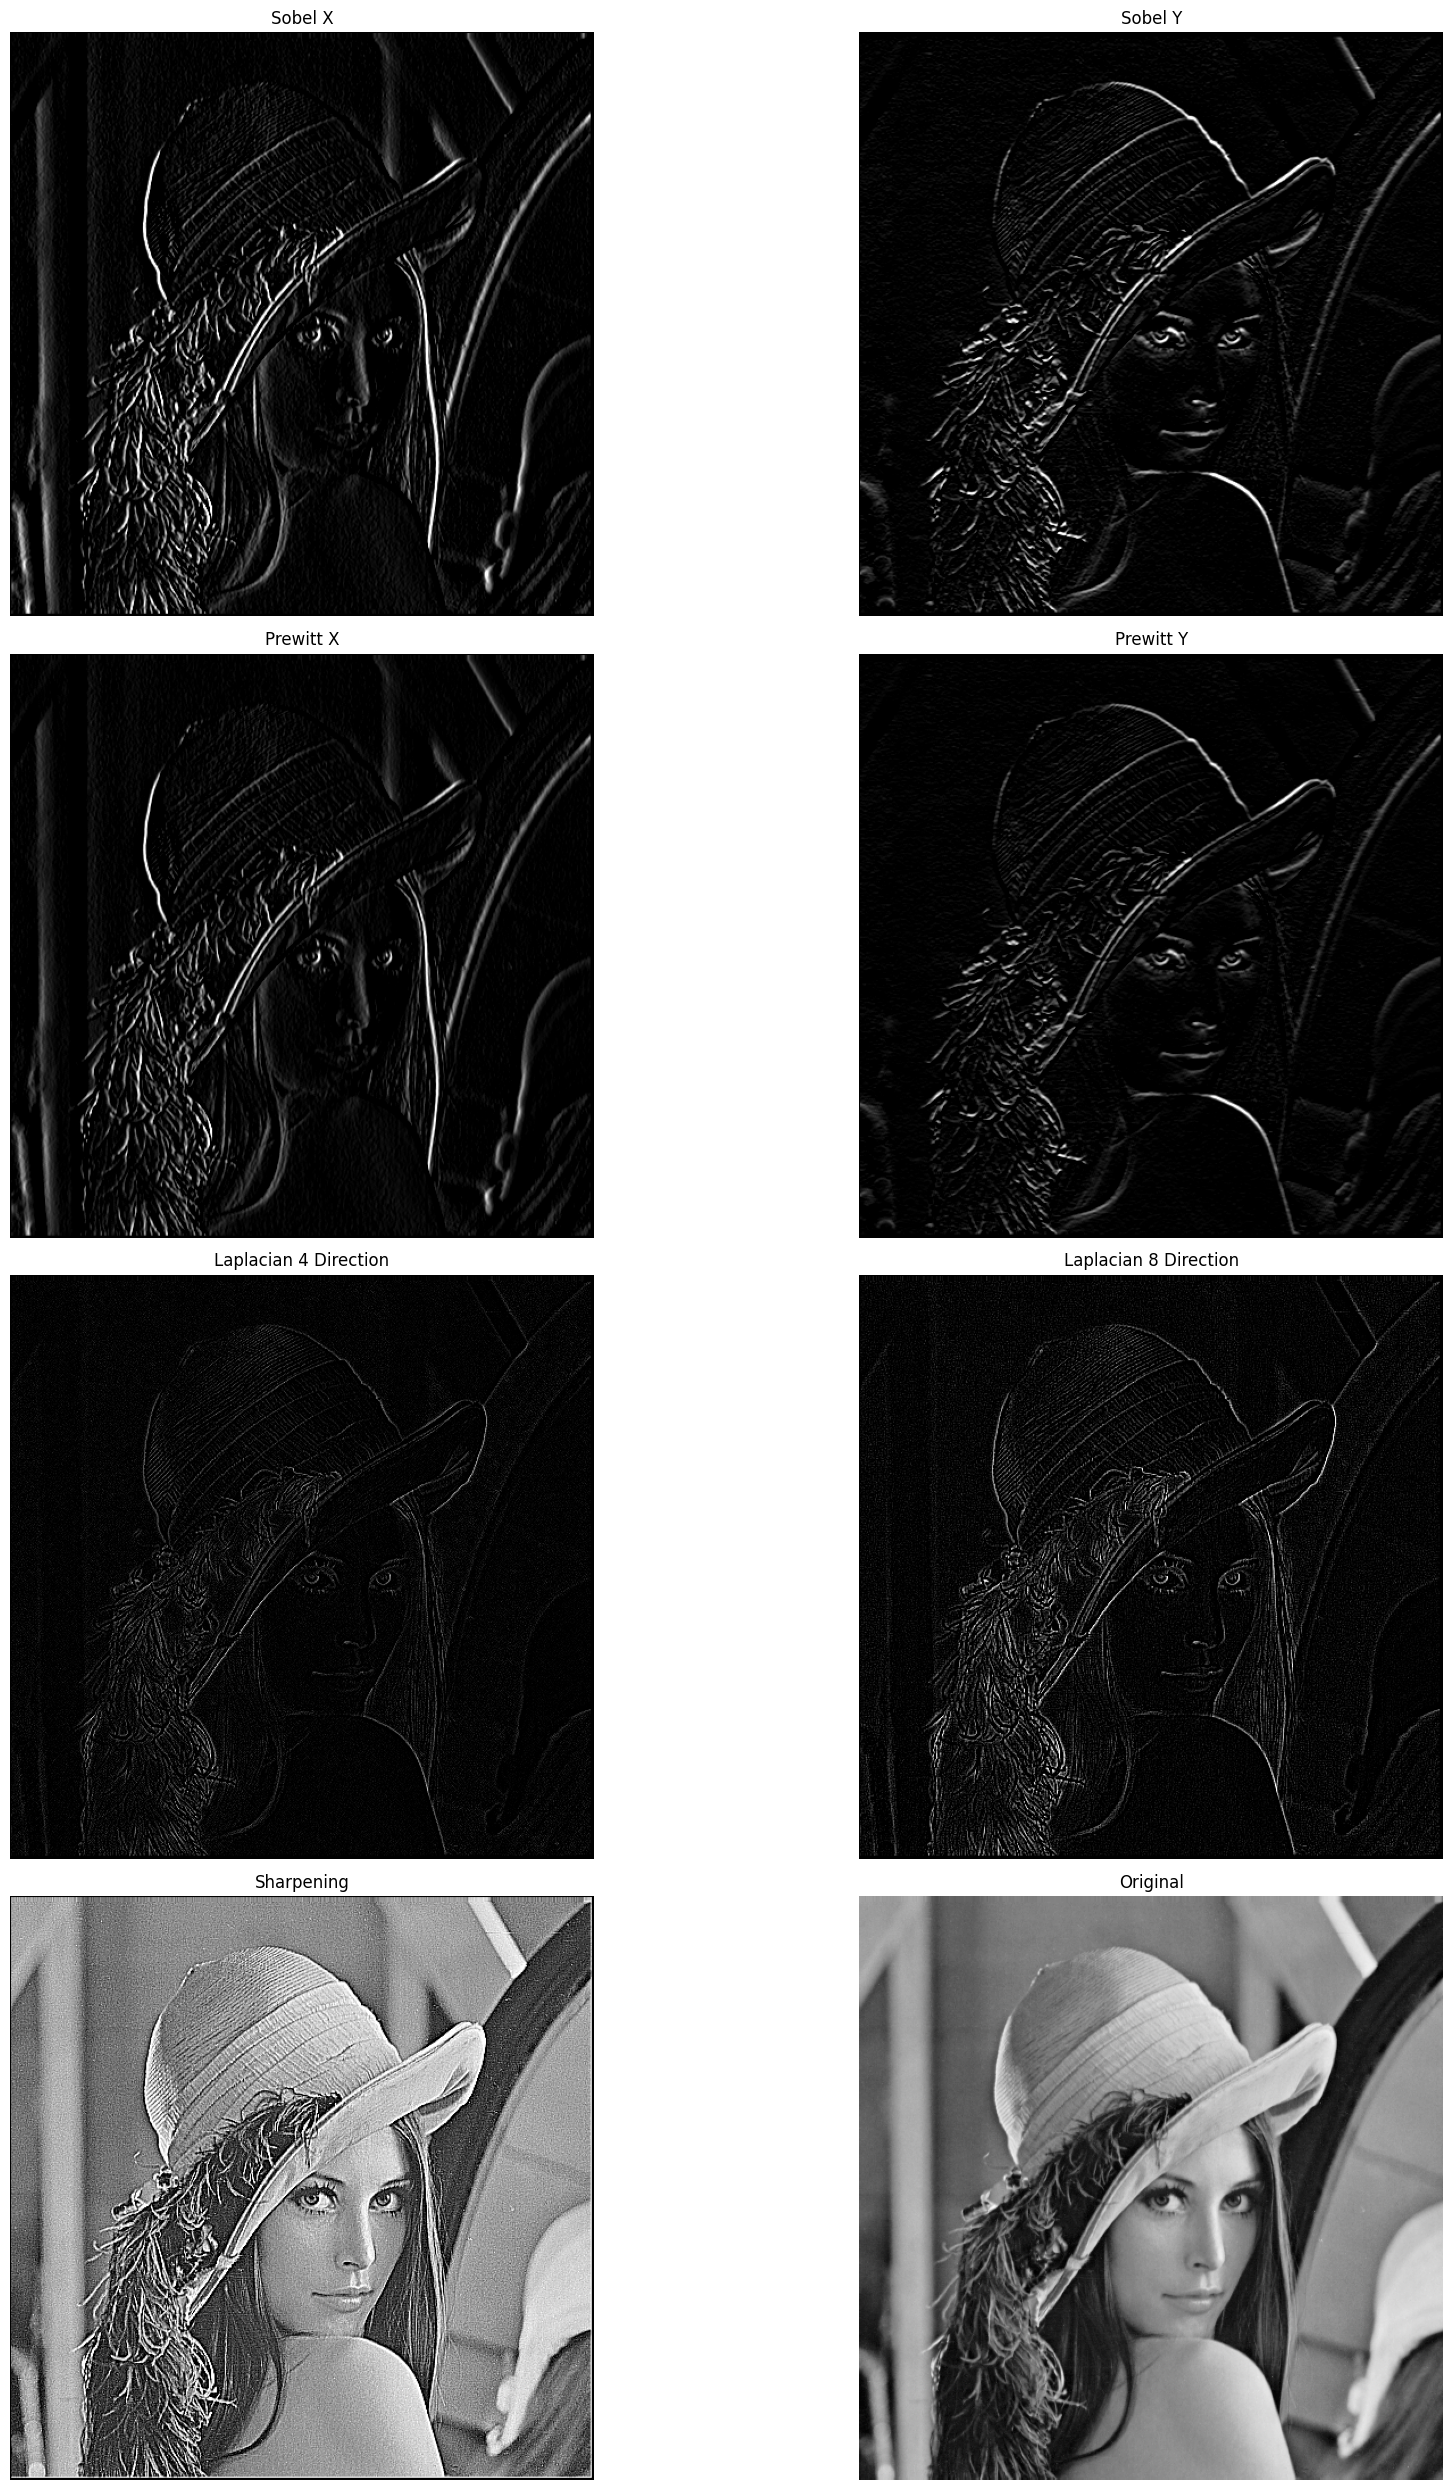

In [29]:
fig, axes = plt.subplots(4, 2, figsize=(20, 25))

titles = [
    ("Sobel X", "Sobel Y"),
    ("Prewitt X", "Prewitt Y"),
    ("Laplacian 4 Direction", "Laplacian 8 Direction"),
    ("Sharpening", "Original"),
]

images = [
    (sobel_filtered_img_x, sobel_filtered_img_y),
    (prewitt_filtered_img_x, prewitt_filtered_img_y),
    (laplacian_filtered_img_4, laplacian_filtered_img_8),
    (sharpening_filtered_img, img),
]

for row, ((t1, t2), (img1, img2)) in enumerate(zip(titles, images)):
    axes[row, 0].imshow(img1, cmap="gray")
    axes[row, 0].set_title(t1)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(img2, cmap="gray")
    axes[row, 1].set_title(t2)
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()
